# Multi-panel probing figures from saved predictions

No experiments are re-run. Everything below reads prediction files that already
exist on disk. All figures render inline first (`show=True`, `save_path=None`);
saving is a separate cell at the end.

Directories are **not** globbed and string-parsed here. `find_probe_runs()` in
`prob.paths_and_io` is the read-side inverse of `get_out_dir()` / `get_exp_dirs()`:
it walks what actually ran and decodes the experimental factors back out of the
path, so this notebook never restates the layout convention.

Reused as-is: `prob.prob_plots.plot_parity` / `plot_conditions_box`,
`prob.plot_multipanel.parity_on_ax` / `plot_parity_grid` / `plot_metric_box`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

from prob.paths_and_io import (
    find_probe_runs, attach_run_metrics, load_run_predictions, 
    get_out_dir, get_data_dir, _parse_rmsd
)
from prob.prob_plots import plot_parity, plot_conditions_box
from prob.plot_multipanel import parity_on_ax, plot_parity_grid, plot_metric_box, plot_run_grid

pd.set_option("display.width", 200)


## 1. What actually ran

`find_probe_runs()` indexes every probe run that has a saved predictions CSV,
one row per (gnn, rmsd, split, target, probe, layer). Call it with no arguments
first to see the whole sweep -- this is also the honest answer to "which cells
of the design are still missing".

In [2]:
all_runs = find_probe_runs()
print(len(all_runs), "probe runs on disk\n")
print(all_runs.groupby(["gnn_model_type", "rmsd_threshold", "split_type"]).size(), "\n")
print("targets:", sorted(all_runs.target.unique()))
print("probes :", sorted(all_runs.prob_model.unique()))
print("layers :", sorted(all_runs.layer.dropna().unique()))

all_runs.head()

796 probe runs on disk

gnn_model_type  rmsd_threshold  split_type         
CGNN            2.0             random-k-fold          130
                6.0             random-k-fold          110
CGNN-3D         2.0             local_random-k-fold      9
                                random-k-fold          185
                6.0             random-k-fold          110
DTI             2.0             random-k-fold          140
                6.0             random-k-fold          112
dtype: int64 

targets: ['affinity', 'docking_score', 'hbond_score_no_mw', 'hydrogen_bonds', 'hydrophobic_interactions', 'mw', 'nitrogen_counts', 'targets', 'weighted_hb_score']
probes : ['lasso', 'mlp', 'random_forest', 'ridge']
layers : [0, 1, 2, 3, 4]


,gnn_model_type,rmsd_threshold,split_type,target,target_full,is_baseline,prob_model,layer,exp_root,predictions_path,summary_path,figures_dir
0,CGNN,2.0,random-k-fold,affinity,affinity,False,lasso,1,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
1,CGNN,2.0,random-k-fold,affinity,affinity,False,lasso,2,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
2,CGNN,2.0,random-k-fold,affinity,affinity,False,lasso,3,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
3,CGNN,2.0,random-k-fold,affinity,affinity,False,mlp,1,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
4,CGNN,2.0,random-k-fold,affinity,affinity,False,mlp,2,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...


## 2. Narrow to this figure's slice

Same function, with filters. Every keyword takes a scalar or a list. The factor
columns (`prob_model`, `layer`, `target`, `is_baseline`, ...) are already decoded,
so downstream selection is plain dataframe filtering -- no path strings.

`attach_run_metrics` folds in what each run wrote to
`reports/<probe>_summary.json`: r2 / rmse / mae, sample counts, and the bootstrap
CIs. Reading them rather than recomputing keeps the box plots consistent with the
per-experiment figures by construction.

In [6]:
# The one cell that picks *which* slice of the sweep this figure set is about.
GNN, RMSD, SPLIT = "DTI", 6, "random-k-fold"
TARGET = "affinity"

In [7]:
runs = find_probe_runs(
    gnn_model_type=GNN, rmsd_threshold=RMSD, split_type=SPLIT, target=TARGET,
)
runs = attach_run_metrics(runs)

runs[["target_full", "is_baseline", "prob_model", "layer",
      "r2", "rmse", "mae", "n_test_samples"]]

,target_full,is_baseline,prob_model,layer,r2,rmse,mae,n_test_samples
0,affinity,False,lasso,1,0.181375,1.149960,0.920208,9341
1,affinity,False,lasso,2,0.196005,1.139638,0.910336,9341
2,affinity,False,lasso,3,0.200565,1.136402,0.907448,9341
3,affinity,False,mlp,1,0.278125,1.079870,0.856930,9341
4,affinity,False,mlp,2,0.361753,1.015394,0.782707,9341
5,affinity,False,mlp,3,0.391602,0.991367,0.765316,9341
6,affinity,False,random_forest,1,0.164692,1.161619,0.942163,9341
7,affinity,False,random_forest,2,0.161730,1.163677,0.942872,9341
8,affinity,False,random_forest,3,0.163346,1.162555,0.941976,9341
9,affinity,False,ridge,1,0.181439,1.149916,0.920254,9341


## 3. Sanity check one panel with the *existing* `plot_parity`

`load_run_predictions(row)` reads the CSV for one run and validates its columns.
If this panel looks right, the grid version will too -- `parity_on_ax` draws the
same joint panel.

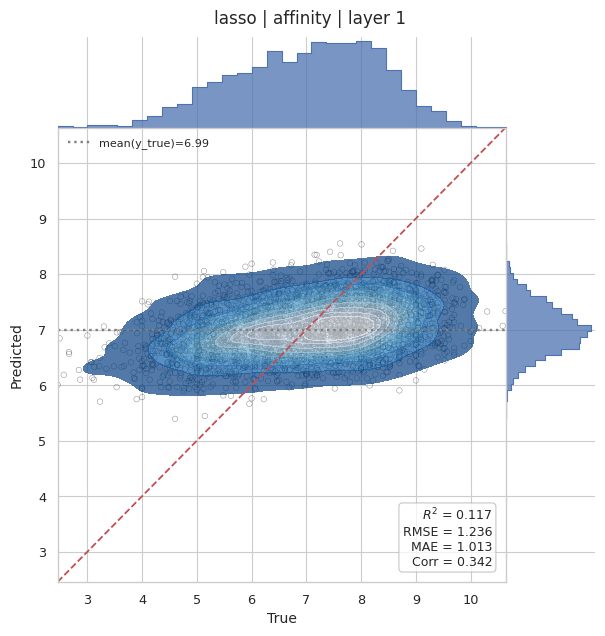

In [6]:
row = runs.iloc[0]
y_true, y_pred = load_run_predictions(row)
plot_parity(y_true, y_pred, density="kde", show=True,
            title=f"{row.prob_model} | {row.target_full} | layer {row.layer}")

## 4. The multi-panel figure

Build `panels` in the order you want them to appear -- insertion order is
preserved. Start with one row to check spacing before going to a full grid.

`shared_lims=True` matters here: with per-panel limits a mean-collapsed panel
and a well-spread one look deceptively similar.

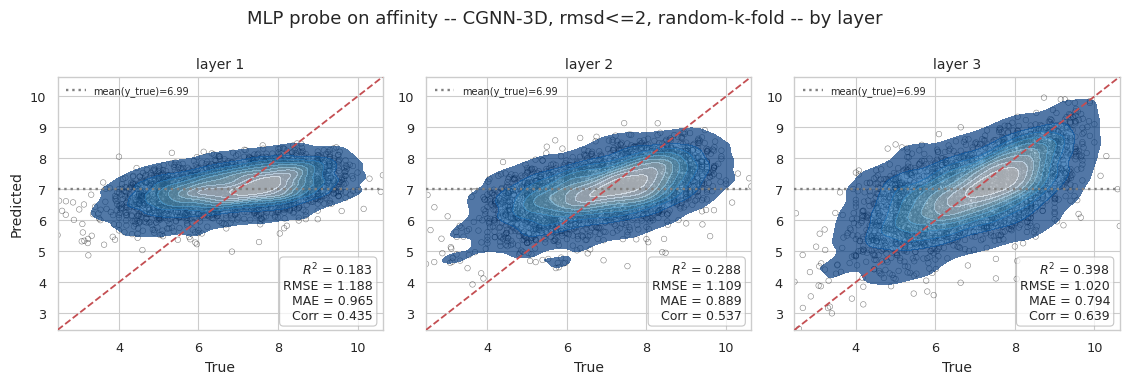

In [8]:
sel = runs[(runs.prob_model == "mlp") & (~runs.is_baseline)].sort_values("layer")

panels = {
    f"layer {r.layer}": load_run_predictions(r)
    for r in sel.itertuples()
}

plot_parity_grid(
    panels, ncols=len(panels), panel_size=3.8,
    density="kde", marginals=False, show_mean_line=True,
    suptitle=f"MLP probe on {TARGET} -- {GNN}, rmsd<={RMSD}, {SPLIT} -- by layer",
    show=True,
)

Variants worth trying before committing:
- `marginals=True` -- restores the JointGrid histograms per panel (needs
  `panel_size >= 4` or they crowd the metrics box)
- `density="kde"` -- smoother, slower at high pair counts
- `row_labels=[...]` with `ncols` set to the column factor, for a
  probe-type x layer matrix

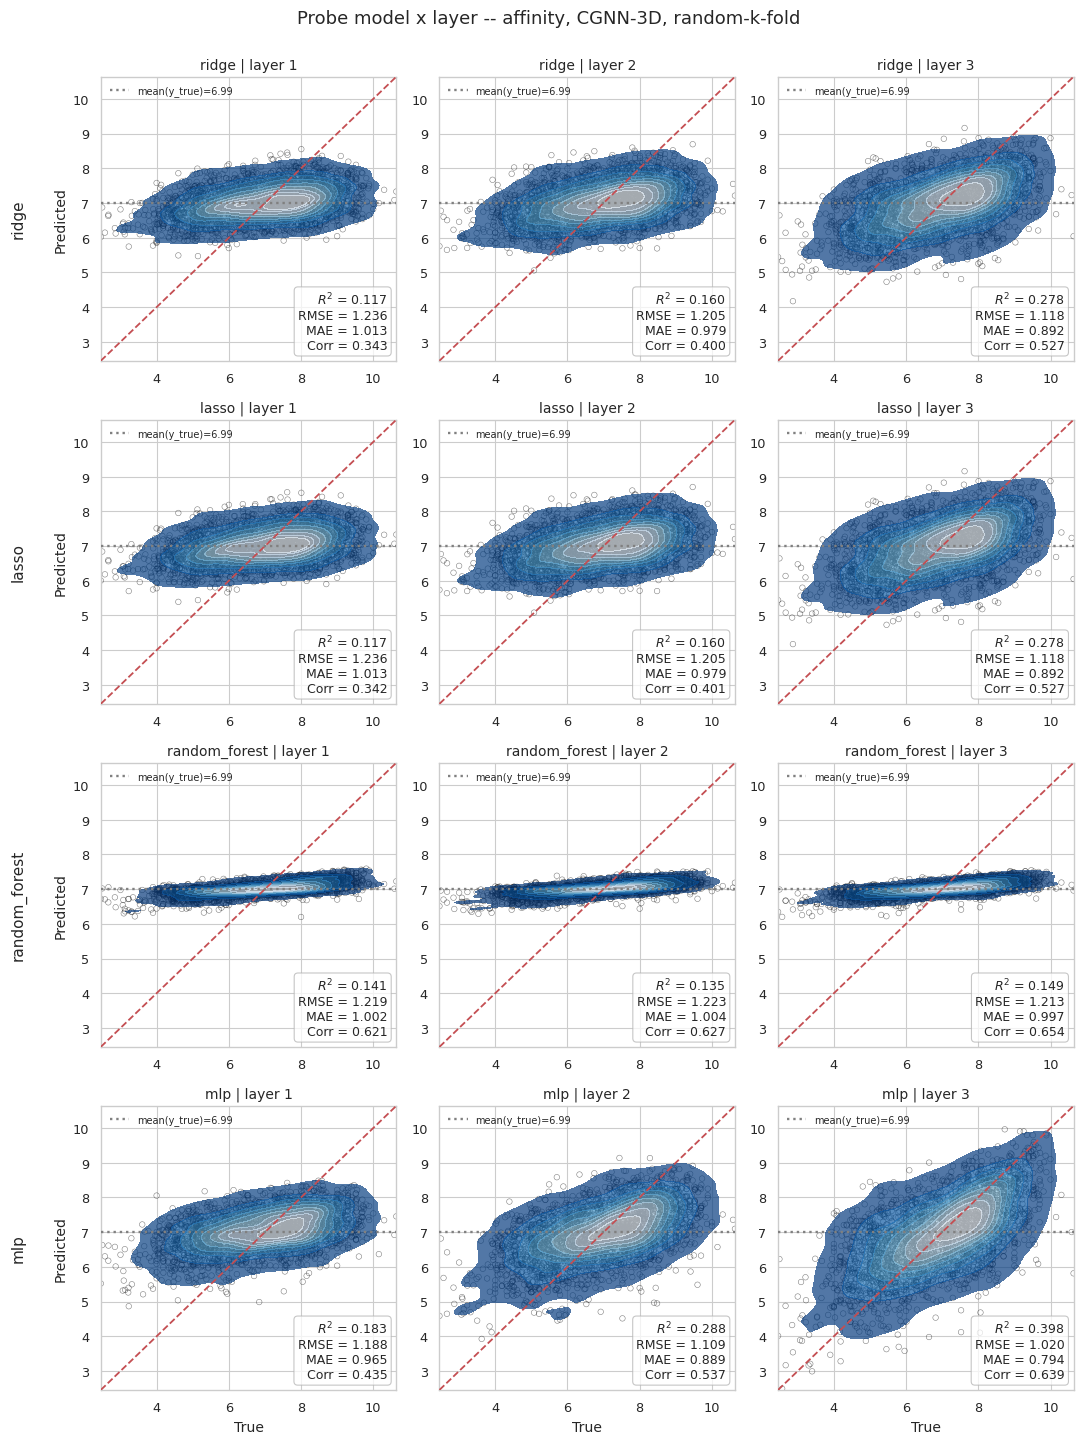

In [ ]:
# probe model (rows) x layer (cols), real target only
GNN, RMSD, SPLIT = "DTI", 2, "random-k-fold"
TARGET = "affinity"

sub = runs[~runs.is_baseline]
probe_order = ["ridge", "mlp","random_forest",   "lasso"]
layer_order = sorted(sub.layer.dropna().unique())

panels2, present = {}, []
for pm in probe_order:
    block = sub[sub.prob_model == pm]
    if block.empty:
        continue
    present.append(pm)
    for L in layer_order:
        r = block[block.layer == L]
        if len(r):
            panels2[f"{pm} | layer {L}"] = load_run_predictions(r.iloc[0])

plot_parity_grid(panels2, ncols=len(layer_order), panel_size=3.6,
                 density="kde", row_labels=present,
                 suptitle=f"Probe model x layer -- {TARGET}, {GNN}, {SPLIT}, -", show=True,
                 save_path=get_data_dir() / "targets" / f"probe_x_layer_{TARGET}_{GNN}_rmsd{RMSD}_{SPLIT}.png"
                 )

### 4b. The same thing without the bookkeeping: `plot_run_grid`

The cell above is the pattern every 2D figure repeats -- pick levels, look up the
run per cell, skip the missing ones, label the margins. `plot_run_grid` takes the
runs frame and two factor *column names* and does that part, so a new figure is a
new pair of column names rather than a new loop.

    plot_run_grid(runs, row, col, per=[...])

`per` names the factors held fixed **per figure**: one figure per observed
combination. Anything left neither on an axis nor in `per` collides silently in a
cell -- the function keeps the first run and says so at the end, which is the
cheap way to notice you forgot to pin `rmsd_threshold`.


In [5]:
all_runs.columns

Index(['gnn_model_type', 'rmsd_threshold', 'split_type', 'target', 'target_full', 'is_baseline', 'prob_model', 'layer', 'exp_root', 'predictions_path', 'summary_path', 'figures_dir'], dtype='object')

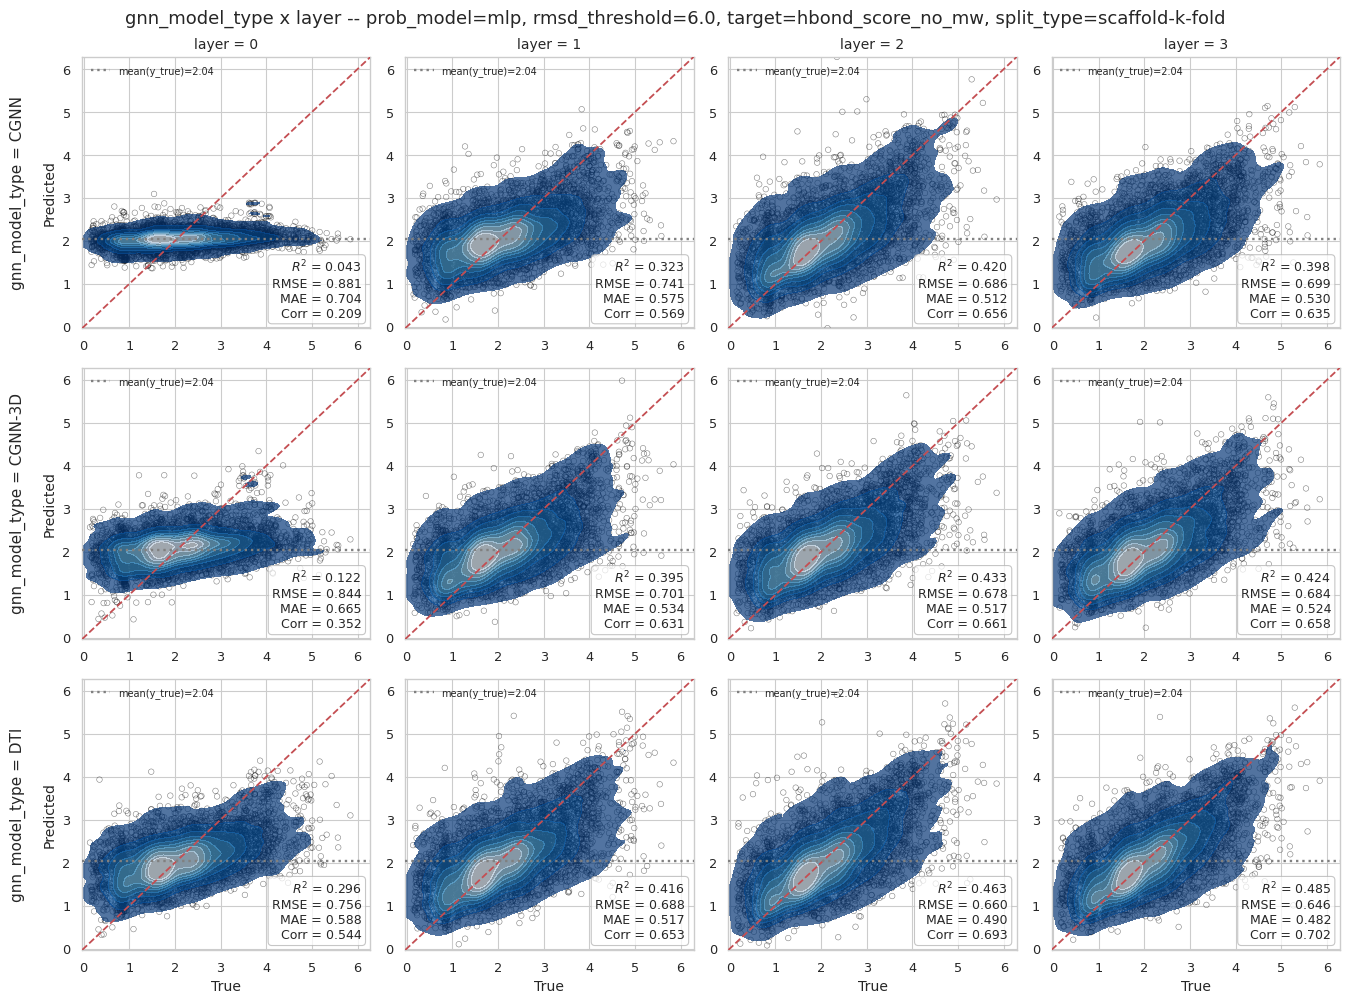

[{'prob_model': 'mlp',
  'rmsd_threshold': 6.0,
  'target': 'hbond_score_no_mw',
  'split_type': 'scaffold-k-fold'}]

In [ ]:
# PROBE_ORDER = ["ridge", "mlp", "lasso", "random_forest"]
ROW_ORDER = ["CGNN-3D", "CGNN", "DTI"]
COL_ORDER = [0, 1, 2, 3]

# it needs to be set, per what the figure is about, to select the right slice of the sweep
# all the possible values are in the printout of the cell above, and in the `all_runs` dataframe.
sweep_params = dict(prob_model="mlp", rmsd_threshold=6, split_type="scaffold-k-fold", target="hbond_score_no_mw")
# save_str = str(get_data_dir() / "targets")
# for k, v in sweep_params.items():
#     save_str += f"_{k}_{v}"

runs = find_probe_runs(**sweep_params)
runs.head(2)
# Same figure as the cell above, from the frame instead of a hand-built dict.
plot_run_grid(
    runs=runs[~runs.is_baseline], row="gnn_model_type", col="layer",
    per=["prob_model", "rmsd_threshold", "target", "split_type"],
    row_order=ROW_ORDER, col_order=COL_ORDER,
    density="kde", panel_size=3.4, show=True,
    save_dir = get_data_dir() / "targets"
)

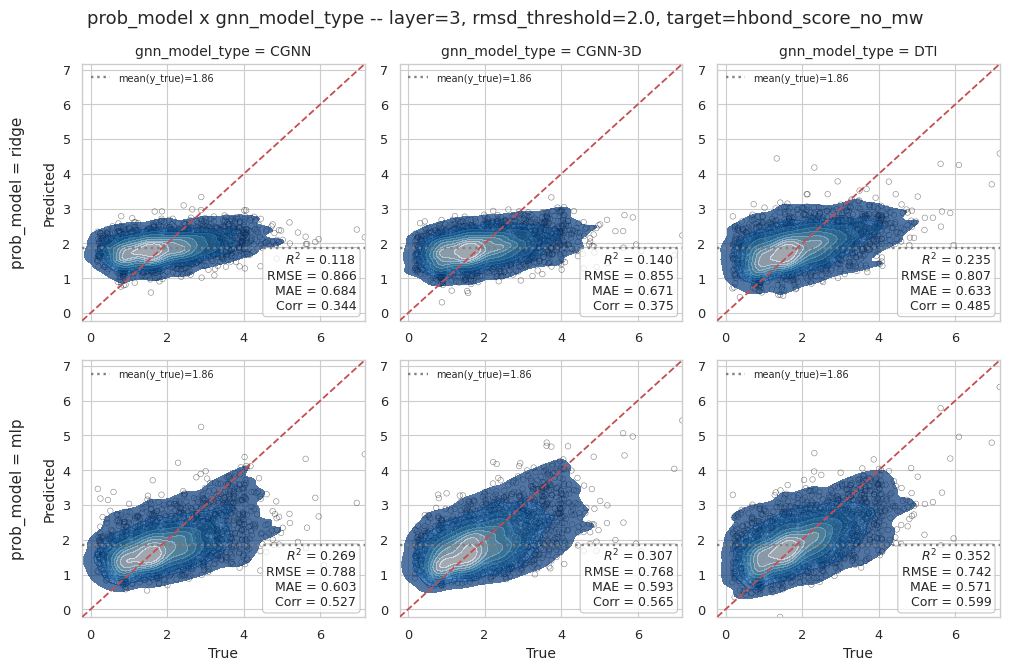

[{'layer': 3, 'rmsd_threshold': 2.0, 'target': 'hbond_score_no_mw'}]

In [ ]:
from prob.plot_multipanel import plot_run_grid

# PROBE_ORDER = ["ridge", "mlp", "lasso", "random_forest"]
ROW_ORDER = ["ridge", "mlp"]

# it needs to be set, per what the figure is about, to select the right slice of the sweep
# all the possible values are in the printout of the cell above, and in the `all_runs` dataframe.
sweep_params = dict(layer=3, rmsd_threshold=2, split_type="random-k-fold", target="hbond_score_no_mw")
# save_str = str(get_data_dir() / "targets")
# for k, v in sweep_params.items():
#     save_str += f"_{k}_{v}"

runs = find_probe_runs(**sweep_params)
# Same figure as the cell above, from the frame instead of a hand-built dict.
plot_run_grid(
    runs=runs[~runs.is_baseline], row="prob_model", col="gnn_model_type",
    per=["layer", "rmsd_threshold", "target"],
    row_order=ROW_ORDER, density="kde", panel_size=3.4, show=True,
    save_dir = get_data_dir() / "targets"
)


In [6]:
runs

,gnn_model_type,rmsd_threshold,split_type,target,target_full,is_baseline,prob_model,layer,exp_root,predictions_path,summary_path,figures_dir
0,CGNN,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,0,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
1,CGNN,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,1,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
2,CGNN,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,2,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
3,CGNN,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,3,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
4,CGNN-3D,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,0,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
5,CGNN-3D,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,1,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
6,CGNN-3D,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,2,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
7,CGNN-3D,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,3,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
8,DTI,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,0,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...
9,DTI,2.0,random-k-fold,hbond_score_no_mw,hbond_score_no_mw,False,mlp,1,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...,/home/fatemeh/thesis/kinodata-3D-affinity-pred...


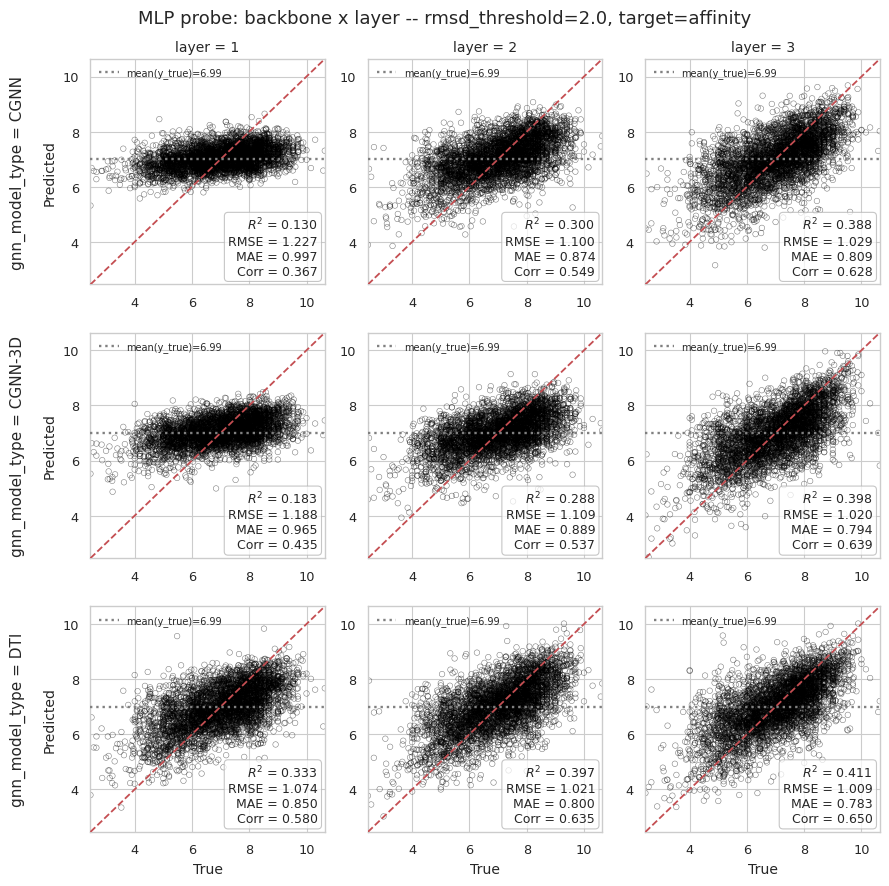

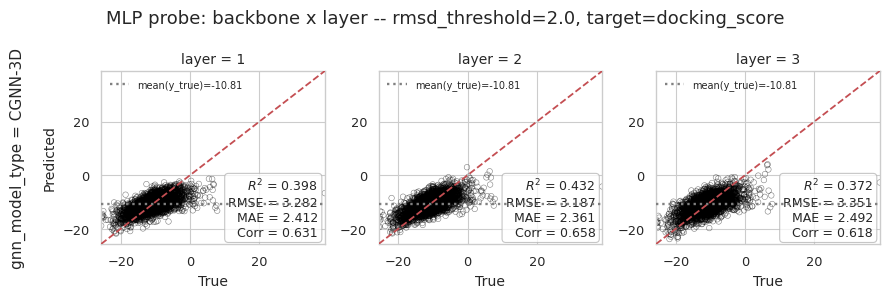

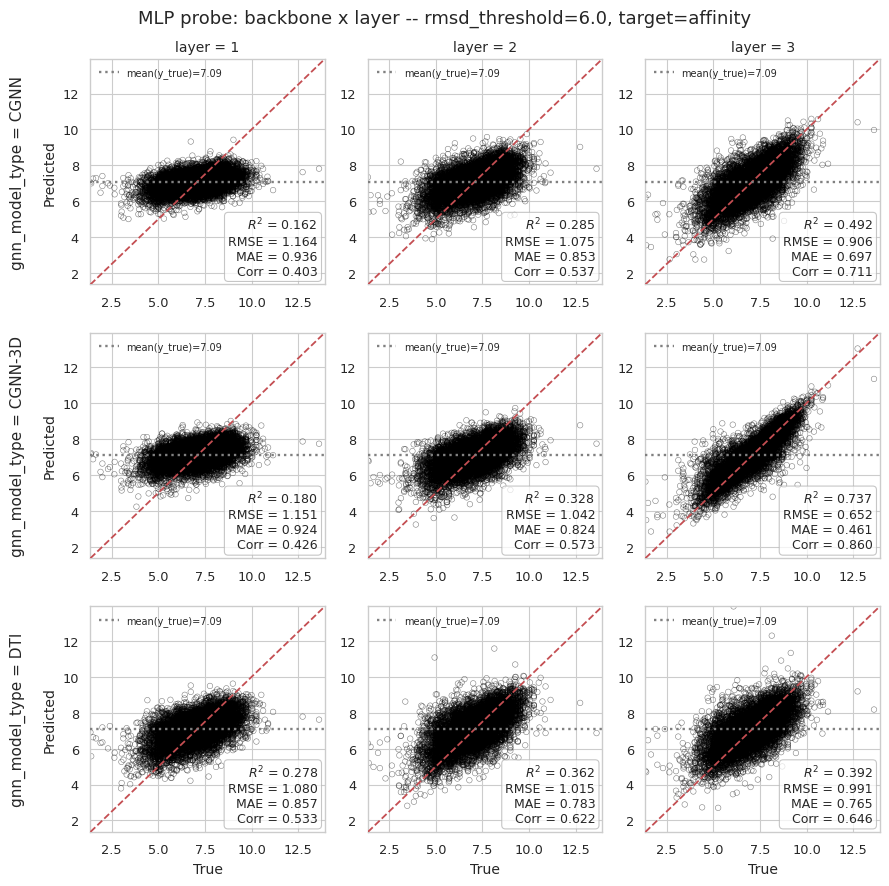

NameError: name 'RMSD' is not defined

In [5]:
# The two axes the notebook could not reach before: they cross the *slice*
# variables, so they need a wider query than `runs`, not different plotting code.
# Keep the target list short -- `per` makes one figure per combination, so an
# unfiltered sweep is dozens of figures.
SPLIT = "random-k-fold"
TARGETS = ["affinity", "docking_score"]
wide = find_probe_runs(split_type=SPLIT, target=TARGETS, include_baselines=False)

# gnn x layer, one figure per (rmsd, target) -- backbone comparison.
plot_run_grid(wide[wide.prob_model == "mlp"], "gnn_model_type", "layer",
              per=["rmsd_threshold", "target"], density=None, panel_size=3.0,
              suptitle="MLP probe: backbone x layer", show=True)

# probe model x gnn, one figure per (target, layer) -- probe-capacity comparison.
plot_run_grid(wide[(wide.rmsd_threshold == RMSD) & (wide.layer == 3)],
              "prob_model", "gnn_model_type", per=["target", "layer"],
              row_order=PROBE_ORDER, density=None, panel_size=3.0, show=True)


### 4c. The GNNs' own predictions (gnn x rmsd)

`data/probing/<gnn>/rmsd_cutoff_*/<split>/predictions.csv` is the backbone's own
affinity prediction, not a probe, and `find_probe_runs` deliberately excludes it
(it is anchored on the `artifacts/` level so the two quantities never get mixed).
It also sits at a shallower depth, so nothing decodes it.

None of that needs a module. `plot_run_grid` only ever reads `predictions_path`
and the two columns you name as axes, and these files already have the
`y_true,y_pred` header `load_run_predictions` expects -- so a six-row frame built
inline is a valid runs frame. Two columns exist because the factors are in the
path; `_parse_rmsd` is the same token decoder the pipeline uses.

Note the columns are **different test sets** (rmsd<=2 is a subset), so read down a
column rather than across a row.


In [4]:
for p in sorted(get_data_dir(prob=True)
                .glob(f"*/rmsd_cutoff_*/{SPLIT}/predictions.csv")):
    print(p)

/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN/rmsd_cutoff_2/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN/rmsd_cutoff_4/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN/rmsd_cutoff_6/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_2/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_4/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_6/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/DTI/rmsd_cutoff_2/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/probing/DTI/rmsd_cutoff_4/scaffold-k-fold/predictions.csv
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/data

,gnn_model_type,rmsd_threshold
0,CGNN,2.0
1,CGNN,4.0
2,CGNN,6.0
3,CGNN-3D,2.0
4,CGNN-3D,4.0
5,CGNN-3D,6.0
6,DTI,2.0
7,DTI,4.0
8,DTI,6.0


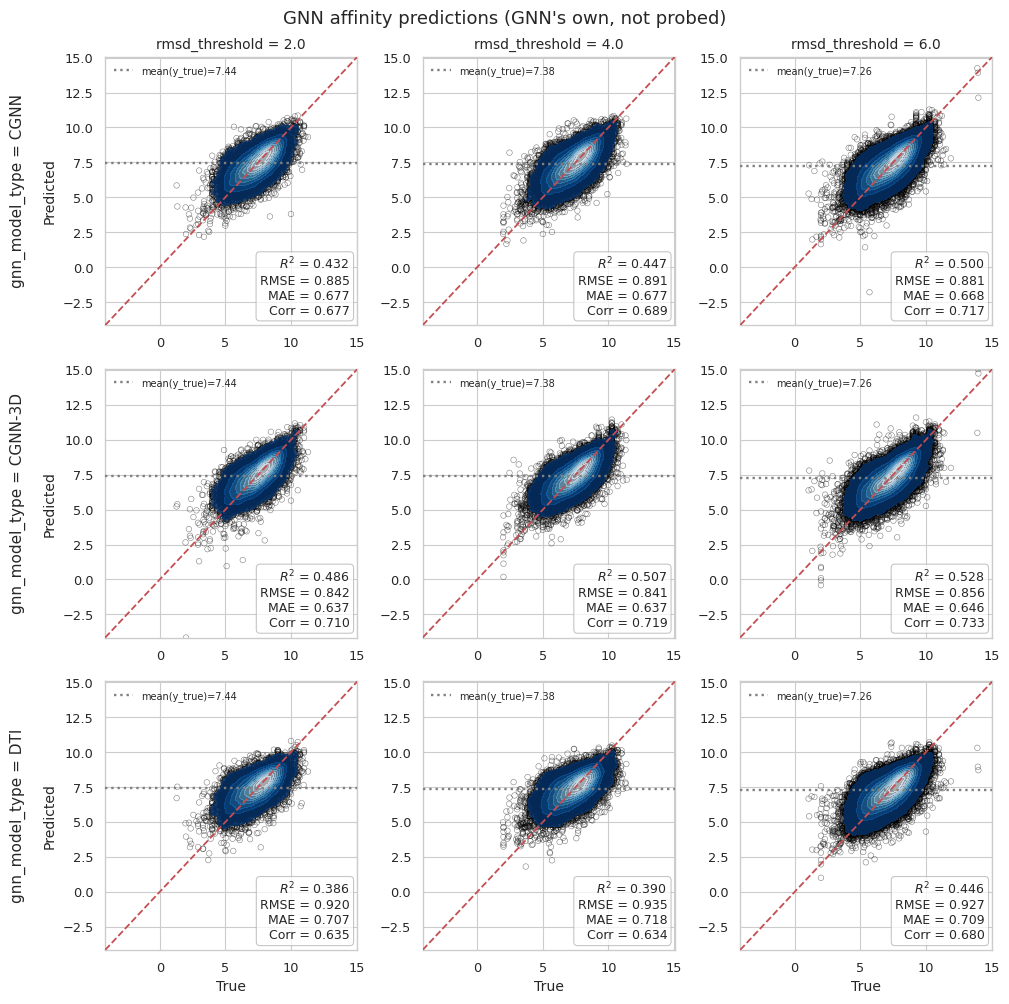

[{}]

In [2]:


SPLIT = "scaffold-k-fold"

gnn_preds = pd.DataFrame(
    [{"gnn_model_type": p.parts[-4],
      "rmsd_threshold": _parse_rmsd(p.parts[-3]),
      "predictions_path": p}
     for p in sorted(get_data_dir(prob=True)
                     .glob(f"*/rmsd_cutoff_*/{SPLIT}/predictions.csv"))]
)
display(gnn_preds[["gnn_model_type", "rmsd_threshold"]])

# 40k-90k pairs per panel: hexbin, and no per-point scatter under it. KDE here
# takes minutes per panel.
plot_run_grid(gnn_preds, "gnn_model_type", "rmsd_threshold",
              density="kde", scatter=True,
              suptitle="GNN affinity predictions (GNN's own, not probed)",
              show=True)
# plot_parity_grid(
#     {f"{r.gnn_model_type} | rmsd {r.rmsd_threshold}": pd.read_csv(r.predictions_path)
#      for r in gnn_preds.itertuples()},
#     ncols=len(gnn_preds.gnn_model_type.unique()), panel_size=3.6,
#     density="kde", marginals=False, show_mean_line=True,
#     suptitle=f"GNN affinity predictions (GNN's own, not probed) -- {SPLIT}",
#     show=True,
# )


## 5. Box plots across runs

The figure that carries the claim; the parity grid is the qualitative companion.
Widen the query rather than the plotting code -- ask `find_probe_runs` for more
of the sweep and let `plot_metric_box` facet it.

In [10]:
# One row per run, across all GNN backbones for this target/split.
summary = attach_run_metrics(
    find_probe_runs(rmsd_threshold=RMSD, split_type=SPLIT, target=TARGET)
)
summary["layer"] = summary["layer"].astype(str)  # categorical axis, keeps layer 0

summary[["gnn_model_type", "target_full", "is_baseline",
         "prob_model", "layer", "r2", "rmse", "mae"]].head()

,gnn_model_type,target_full,is_baseline,prob_model,layer,r2,rmse,mae
0,CGNN,affinity,False,lasso,1,0.148098,1.213672,0.982500
1,CGNN,affinity,False,lasso,2,0.128250,1.227729,0.997817
2,CGNN,affinity,False,lasso,3,0.187389,1.185353,0.958029
3,CGNN,affinity,False,mlp,1,0.129975,1.226513,0.997053
4,CGNN,affinity,False,mlp,2,0.300088,1.100090,0.873592


/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/plot_multipanel.py:225: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.25'` for the same effect.

  sns.stripplot(data=data, x=x, y=y, hue=hue, order=order,
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/plot_multipanel.py:225: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.25'` for the same effect.

  sns.stripplot(data=data, x=x, y=y, hue=hue, order=order,
/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/plot_multipanel.py:225: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.25'` for the same effect.

  sns.stripplot(data=data, x=x, y=y, hue=hue, order=order,


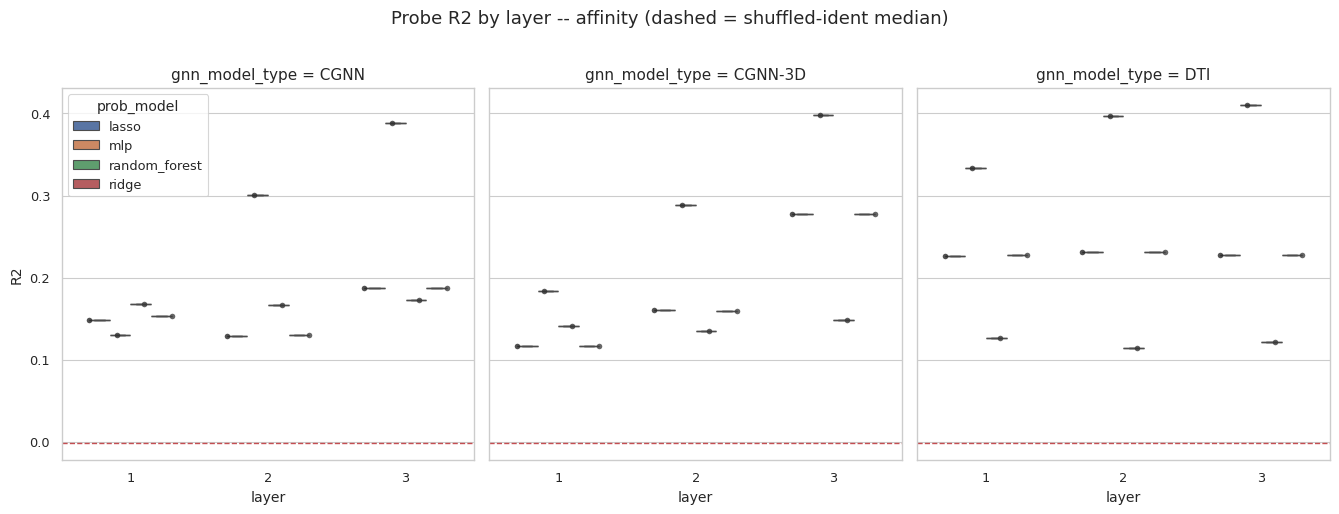

In [11]:
# Shuffled-ident baseline as the reference level, rather than a bare 0.
baseline_r2 = summary.loc[summary.is_baseline, "r2"].median()

plot_metric_box(
    summary[~summary.is_baseline],
    x="layer", y="r2", hue="prob_model", col="gnn_model_type",
    hline=baseline_r2,
    title=f"Probe R2 by layer -- {TARGET} (dashed = shuffled-ident median)",
    show=True,
)

### Caveat: there is no fold dimension at the probe level

The box plot above puts **one point in every box**. That is not a bug in the
query -- `find_probe_runs` returns exactly one run per
(gnn, rmsd, split, target, probe, layer) cell, because `aggregate_predictions`
concatenates the CV folds into a single pooled dataset *before* probing, and the
probe is then fit on one train/test split of that pool. The fold replicates the
Fig-10 style needs are consumed upstream.

So the dispersion to show here is the **bootstrap CI** each run already wrote to
its summary (`r2_ci_lower` / `r2_ci_upper`), not a box over folds. To get real
per-fold boxes instead, the probing pipeline would have to run per fold rather
than on the aggregate -- a pipeline change, not a plotting one.

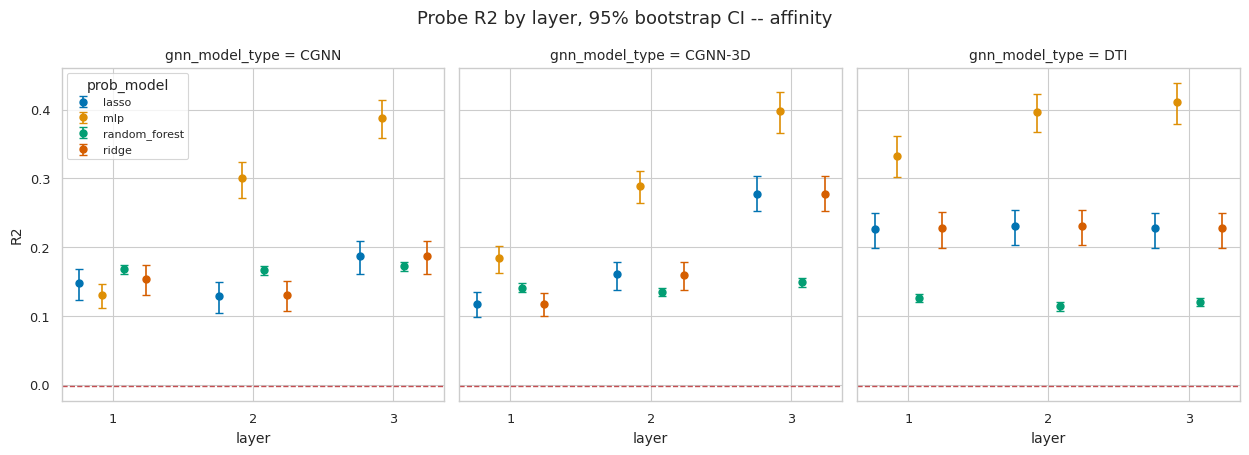

In [ ]:
def plot_metric_ci(df, *, x="layer", y="r2", hue="prob_model", col="gnn_model_type",
                   hline=None, title=None, save_path=None, show=True):
    """Point estimate + bootstrap CI per run, faceted. One run per cell, so the
    error bar is the run's own CI rather than spread across replicates."""
    lo_col, hi_col = f"{y}_ci_lower", f"{y}_ci_upper"
    facets = [None] if col is None else sorted(df[col].unique())
    hues = [None] if hue is None else sorted(df[hue].unique())
    xs = sorted(df[x].unique())

    fig, axes = plt.subplots(1, len(facets), figsize=(4.2 * len(facets), 4.6),
                             squeeze=False, sharey=True)
    palette = dict(zip(hues, sns.color_palette("colorblind", len(hues))))

    for i, facet in enumerate(facets):
        ax = axes[0][i]
        data = df if facet is None else df[df[col] == facet]
        for j, h in enumerate(hues):
            block = data if h is None else data[data[hue] == h]
            block = block.set_index(x).reindex(xs)
            offset = (j - (len(hues) - 1) / 2) * 0.16
            pos = np.arange(len(xs)) + offset
            err = None
            if {lo_col, hi_col}.issubset(block.columns):
                err = np.vstack([block[y] - block[lo_col], block[hi_col] - block[y]])
            ax.errorbar(pos, block[y], yerr=err, fmt="o", capsize=3, markersize=5,
                        color=palette[h], label=str(h) if i == 0 else None)
        if hline is not None:
            ax.axhline(hline, color="r", linestyle="--", linewidth=1.0)
        ax.set_xticks(np.arange(len(xs)), xs)
        ax.set_xlabel(x)
        ax.set_ylabel(y.upper() if i == 0 else "")
        if facet is not None:
            ax.set_title(f"{col} = {facet}", fontsize=10)
    if hue is not None:
        axes[0][0].legend(title=hue, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    if save_path is not None:
        from prob.prob_plots import _resolve_save_path
        fig.savefig(_resolve_save_path(save_path), dpi=200, bbox_inches="tight")
    plt.show() if show else plt.close(fig)


plot_metric_ci(summary[~summary.is_baseline],
               x = "layer", y = "rmse", hue = "prob_model", col = "gnn_model_type",
                hline=baseline_rmse,
               title=f"Probe RMSE by layer, 95% bootstrap CI -- {TARGET}")

Swap `y="r2"` for `"rmse"` or `"mae"`; swap the axes (`x="prob_model"`,
`hue="layer"`, `col="target"`) depending on which contrast you want the reader to
make first. `r2_ci_lower` / `r2_ci_upper` are on the same frame if you would
rather draw the bootstrap interval than a box over probe models.

## 6. Per-sample error distributions (existing function, unchanged)

Different question from the above: this is the spread of errors *within* a run,
not across folds.

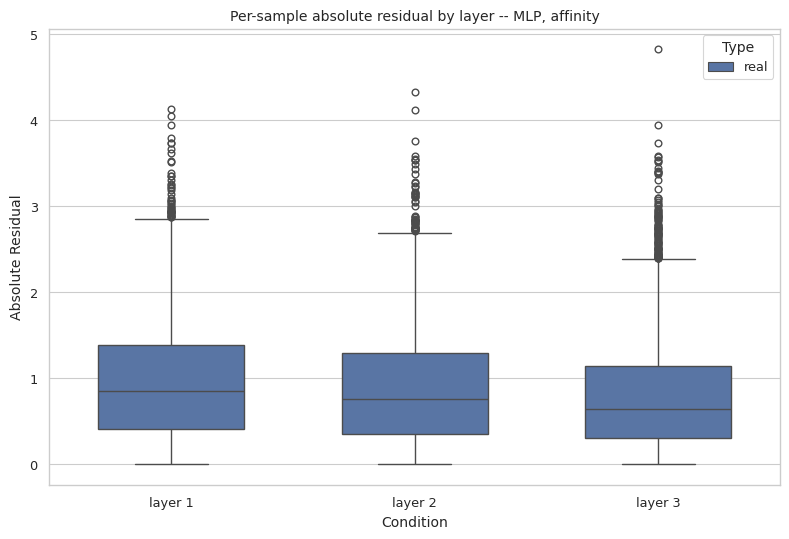

In [13]:
conditions = {
    f"layer {r.layer}": load_run_predictions(r)
    for r in sel.itertuples()
}
plot_conditions_box(conditions, metric="abs_residual",
                    title=f"Per-sample absolute residual by layer -- MLP, {TARGET}",
                    show=True)

## 7. Save the versions you kept

Cross-experiment figures do not belong to any single experiment, so they go to
the split-level root (the parent of the per-target experiment trees) rather than
into one run's `figures/`. `get_out_dir(..., split_fold=None)` is the same
function the pipeline writes with; `_resolve_save_path` then appends `figures/`
and the `.png`.

In [ ]:
FIG_ROOT = get_out_dir(GNN, RMSD, SPLIT, split_fold=None)

plot_parity_grid(panels, ncols=len(panels), panel_size=3.8, density="hexbin",
                 suptitle=f"MLP probe on {TARGET} -- by layer",
                 save_path=FIG_ROOT / f"parity_grid_{TARGET}_mlp_by_layer",
                 show=False)

plot_metric_box(summary[~summary.is_baseline],
                x="layer", y="r2", hue="prob_model", col="gnn_model_type",
                hline=baseline_r2, title=f"Probe R2 by layer -- {TARGET}",
                save_path=FIG_ROOT / f"box_r2_{TARGET}_by_layer", show=False)

sorted((FIG_ROOT / "figures").glob("*.png"))